<a href="https://colab.research.google.com/github/nehasmhs/Beginner_Level/blob/main/Bank_Customer_Churn_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the data set

In [3]:
df = pd.read_csv('Bank_Churn.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [7]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df.shape

(10000, 13)

In [11]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

# Checking for missing values

In [8]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Column Value Counts

In [15]:
for col in df.columns:
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts())
    print()

Value counts for column 'CustomerId':
CustomerId
15656710    1
15768163    1
15672754    1
15719276    1
15692664    1
           ..
15737888    1
15701354    1
15619304    1
15647311    1
15634602    1
Name: count, Length: 10000, dtype: int64

Value counts for column 'Surname':
Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Hull          1
Sturdee       1
Flannagan     1
Dwyer         1
Corby         1
Name: count, Length: 2932, dtype: int64

Value counts for column 'CreditScore':
CreditScore
850    233
678     63
655     54
705     53
667     53
      ... 
358      1
412      1
382      1
373      1
419      1
Name: count, Length: 460, dtype: int64

Value counts for column 'Geography':
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Value counts for column 'Gender':
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Value counts for column 'Age':
Age
37    478
38    477
35    47

# Deep Dive Exploratory Data Analysis

# **Univariate Analysis**

Plotting distribution of numerical columns

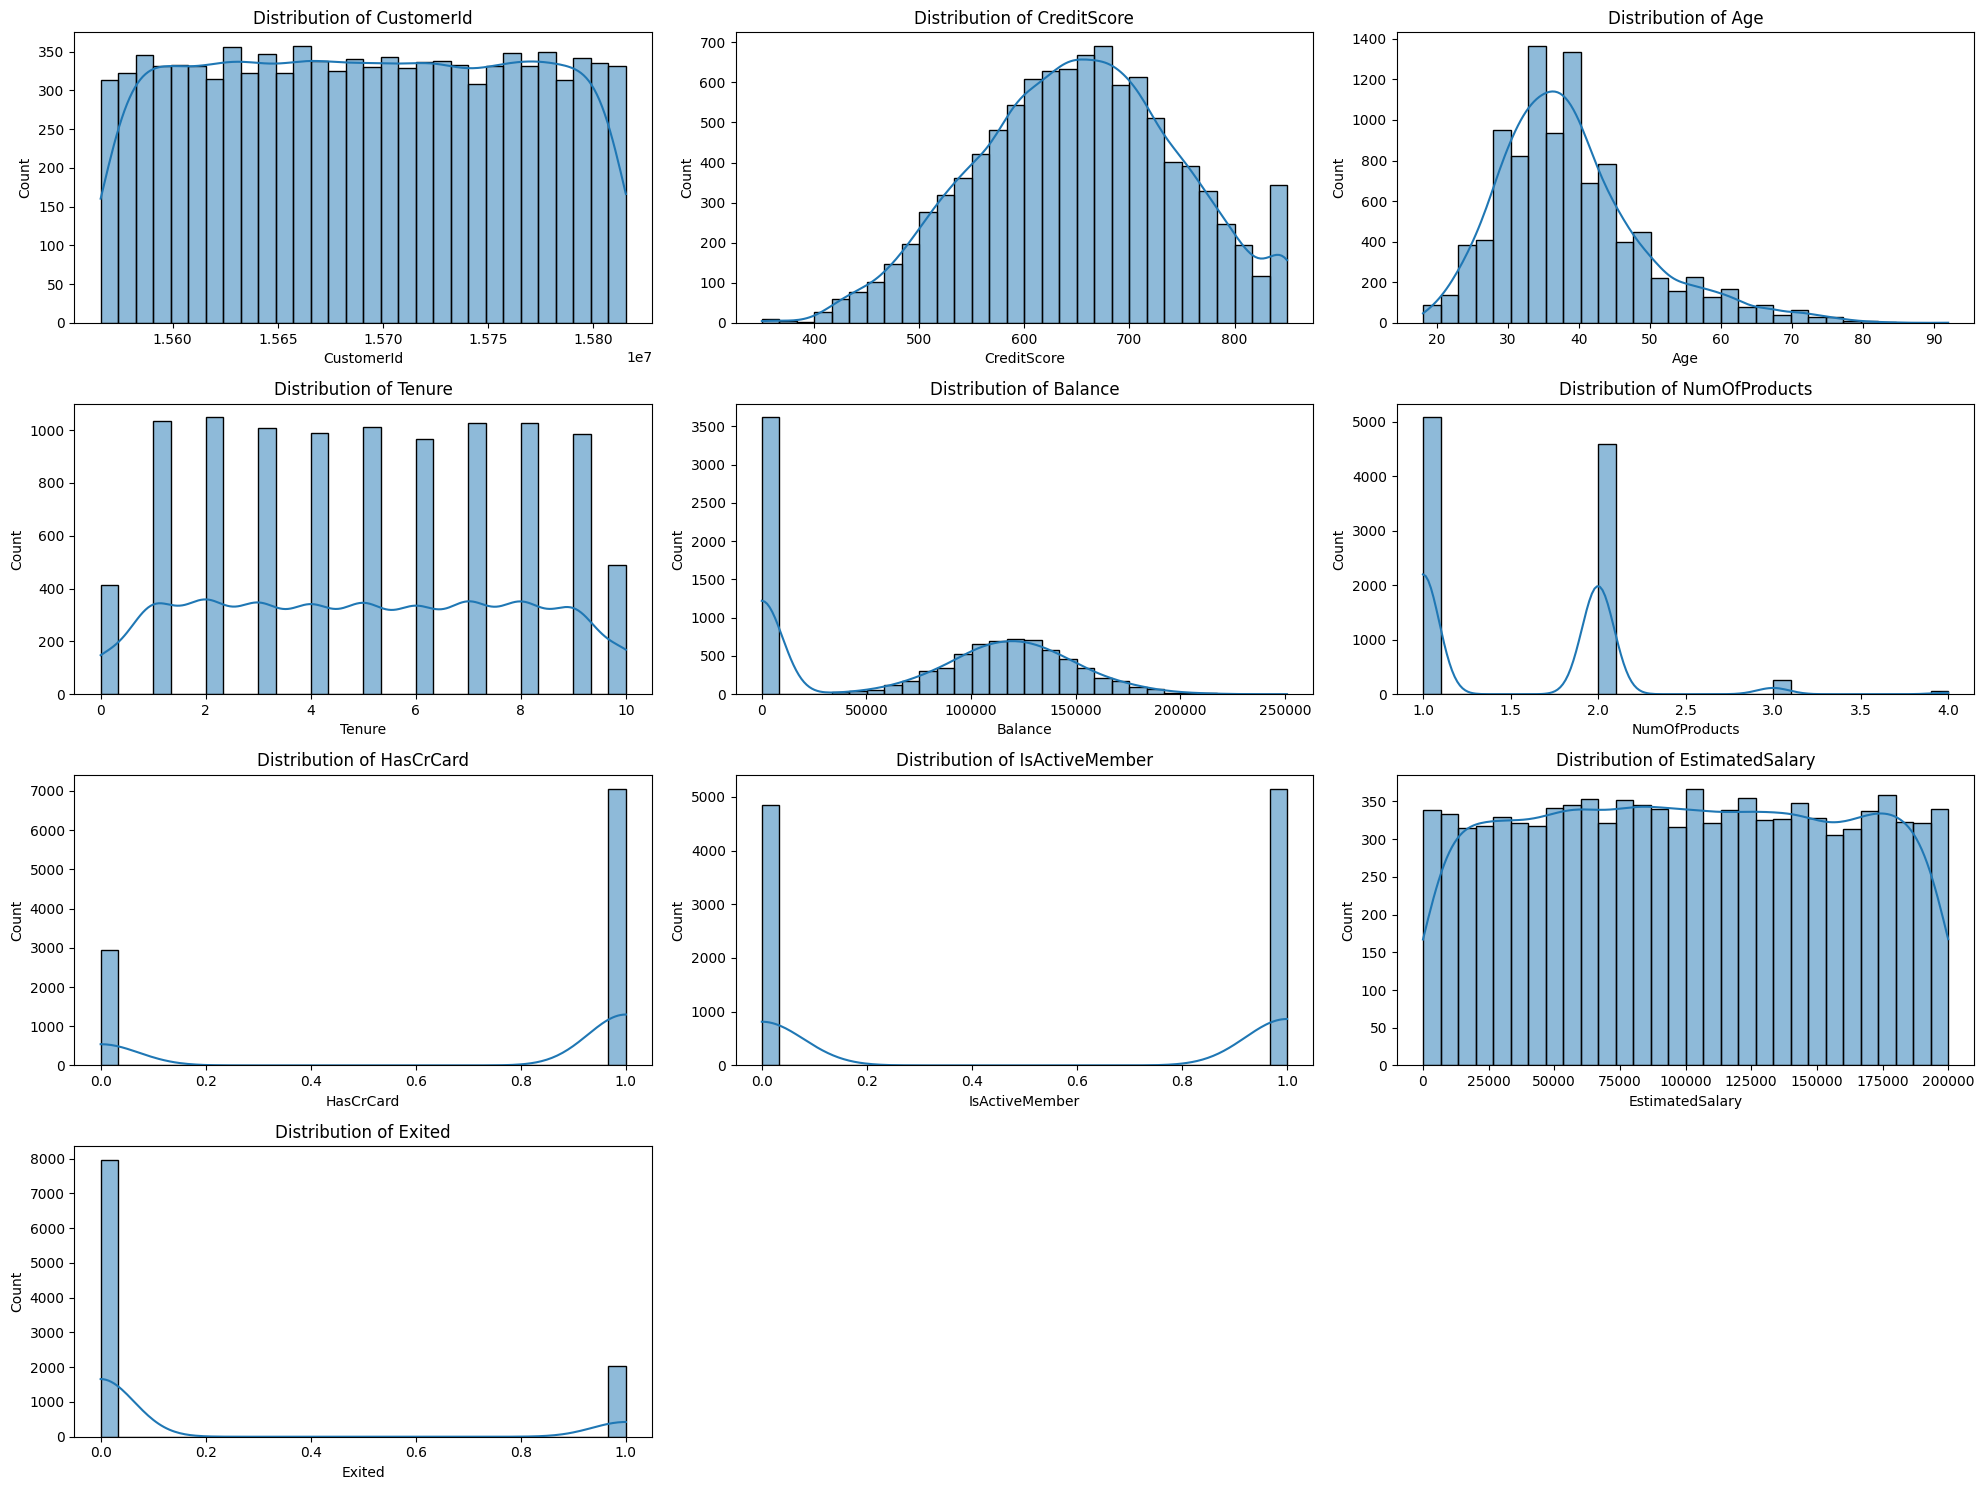

In [16]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

 Plotting value counts for categorical columns

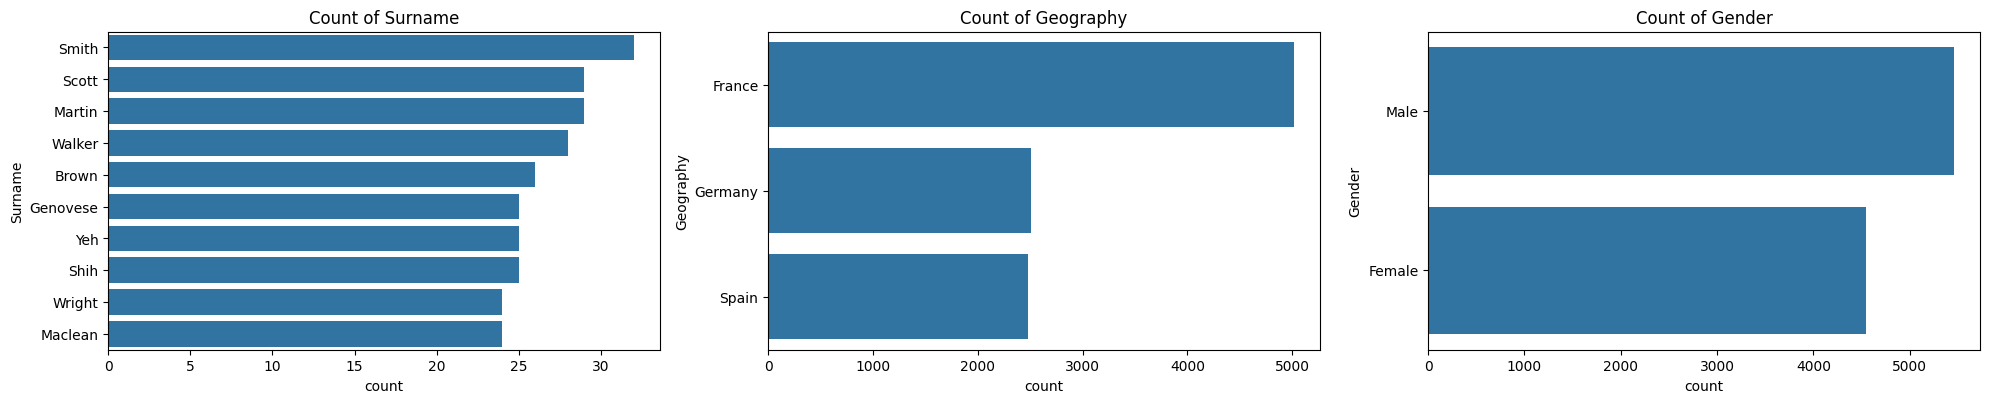

In [18]:
categorical_columns = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 3, i)
    top_10_values = df[col].value_counts().nlargest(10).index
    sns.countplot(y=df[col], order=top_10_values)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

# Bivariate Analysis

**Numerical columns against target variable**

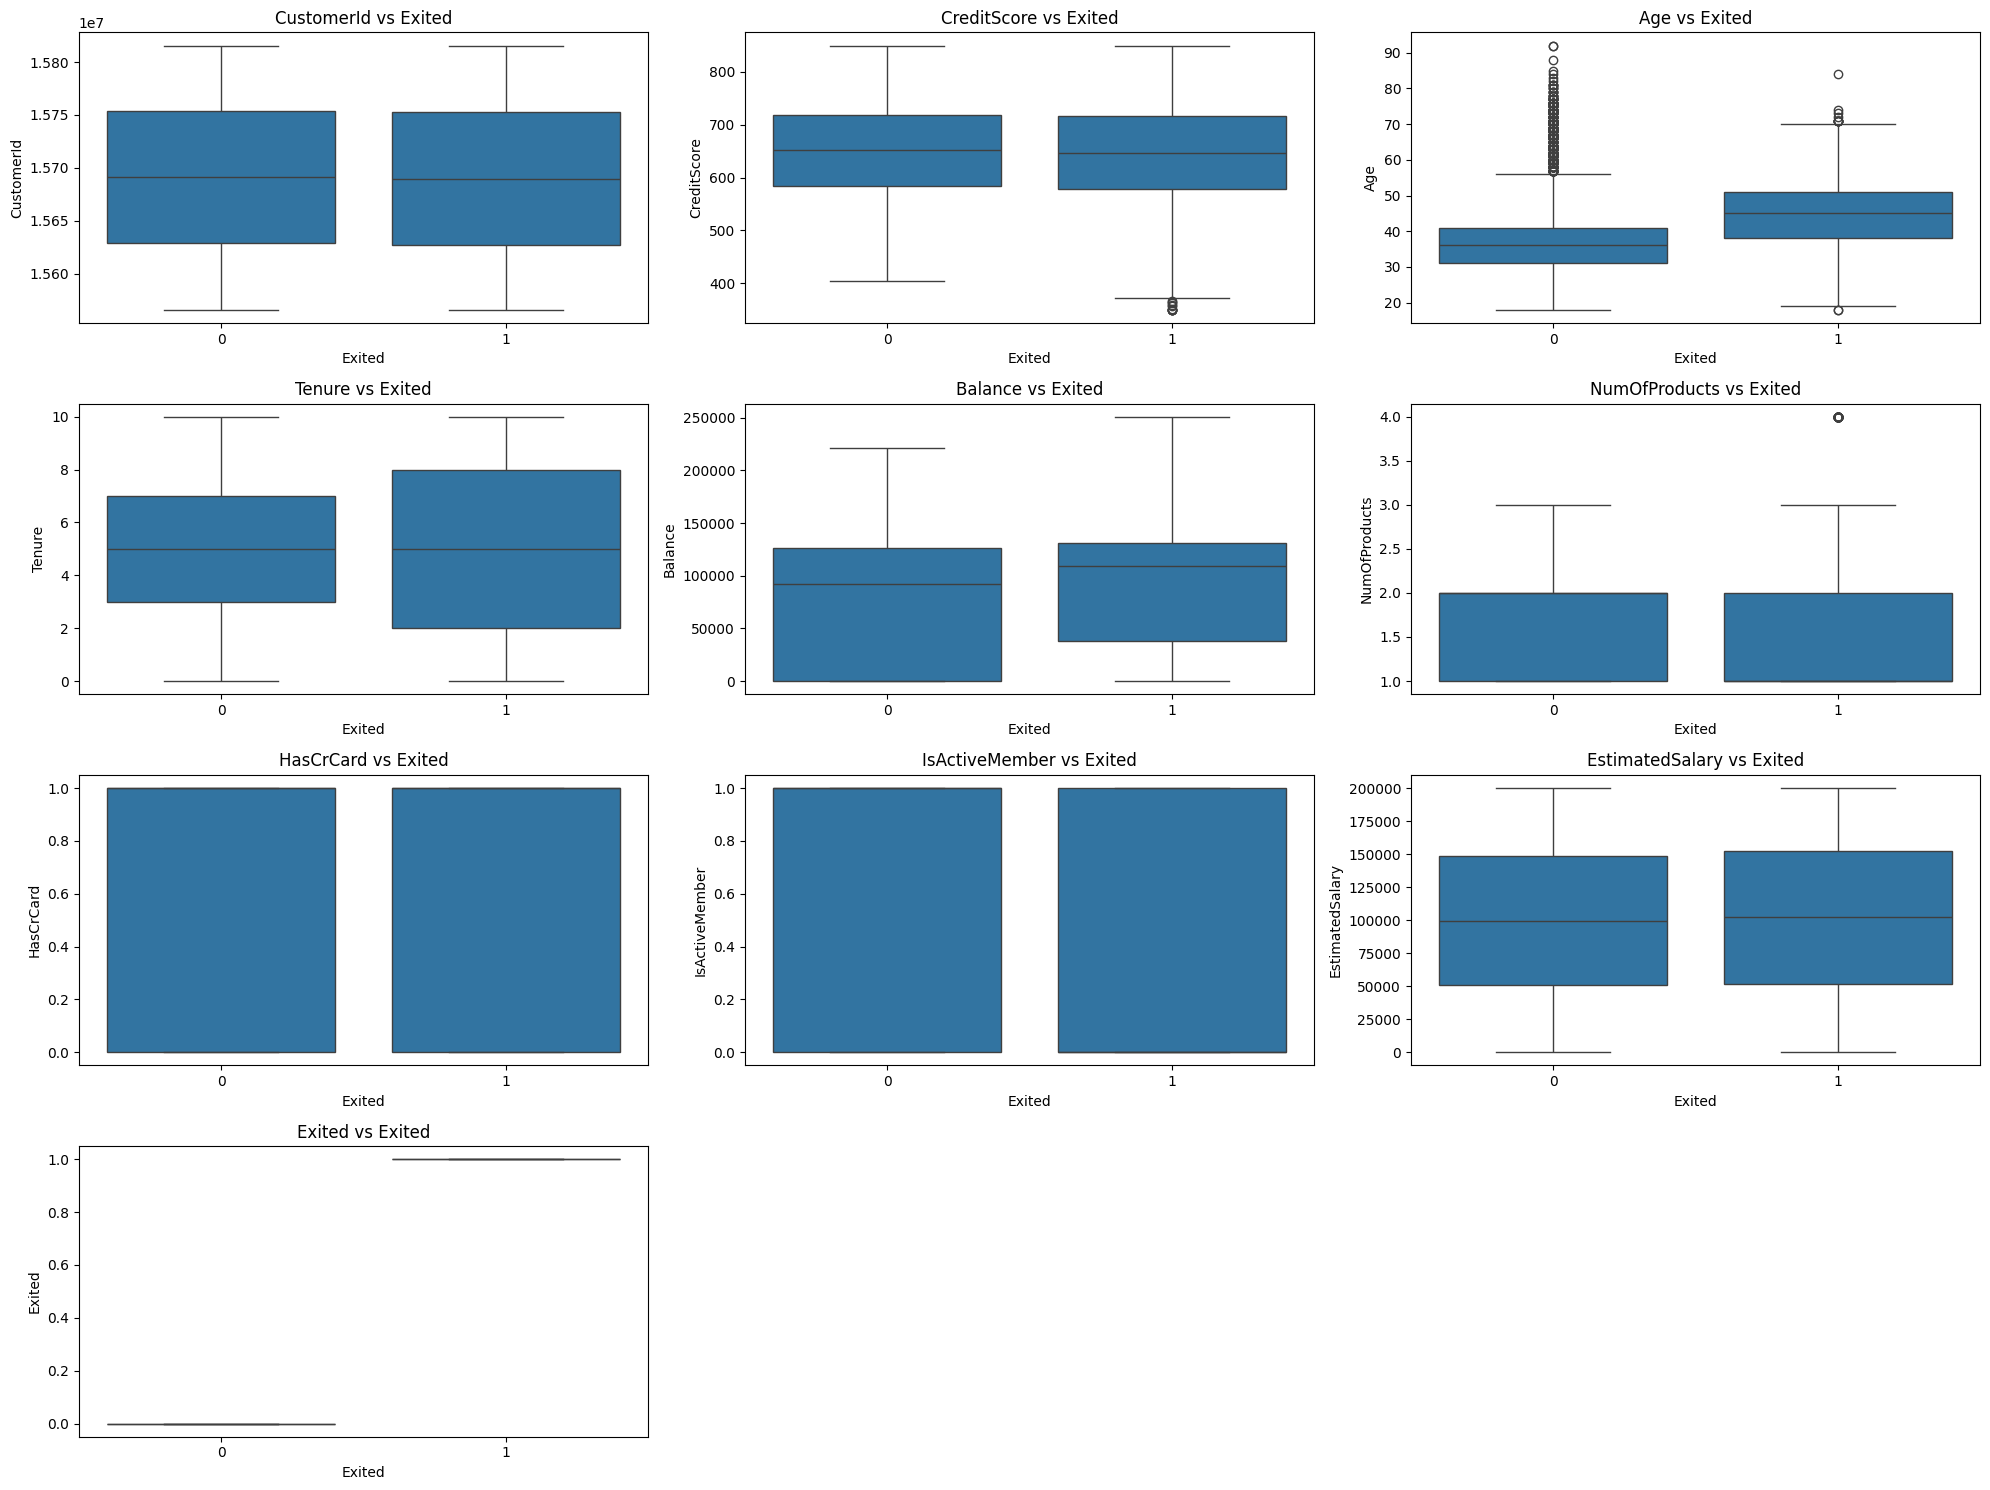

In [19]:
target = 'Exited'

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} vs {target}')
plt.tight_layout()
plt.show()

**Categorical columns against target variable**

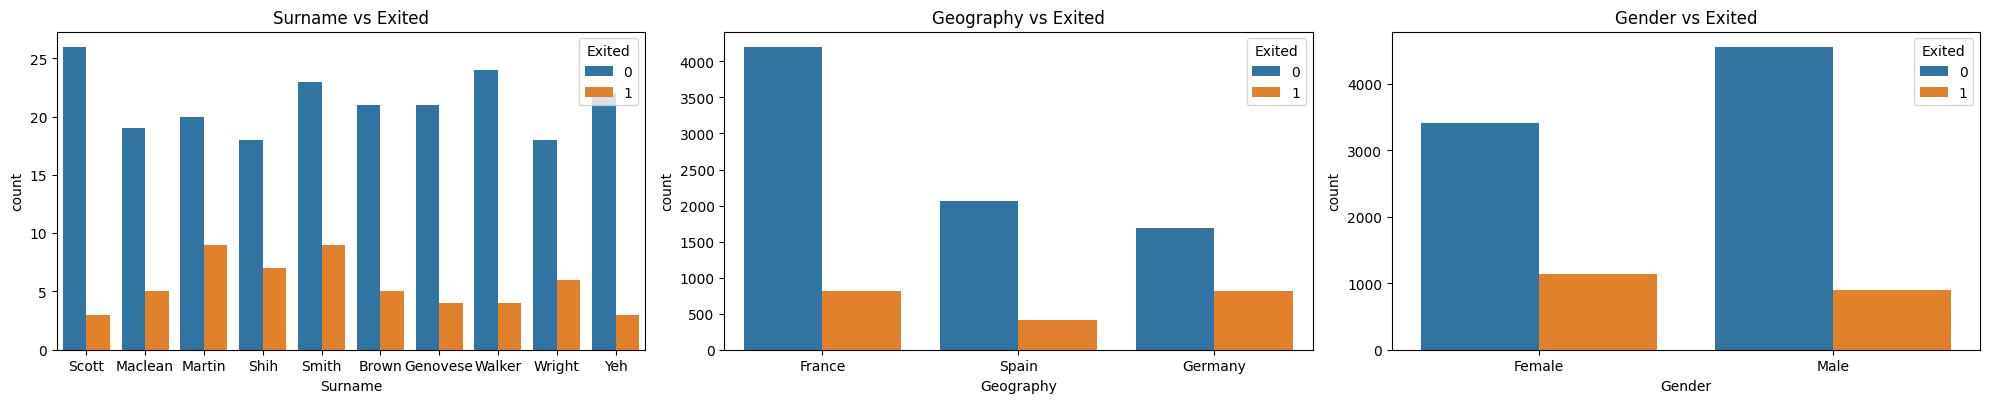

In [20]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 3, i)
    top_10_values = df[col].value_counts().nlargest(10).index
    sns.countplot(x=col, hue=target, data=df[df[col].isin(top_10_values)])
    plt.title(f'{col} vs {target}')
    plt.legend(title=target)
plt.tight_layout()
plt.show()

# Multivariate Analysis

**Pairplot for numerical columns**

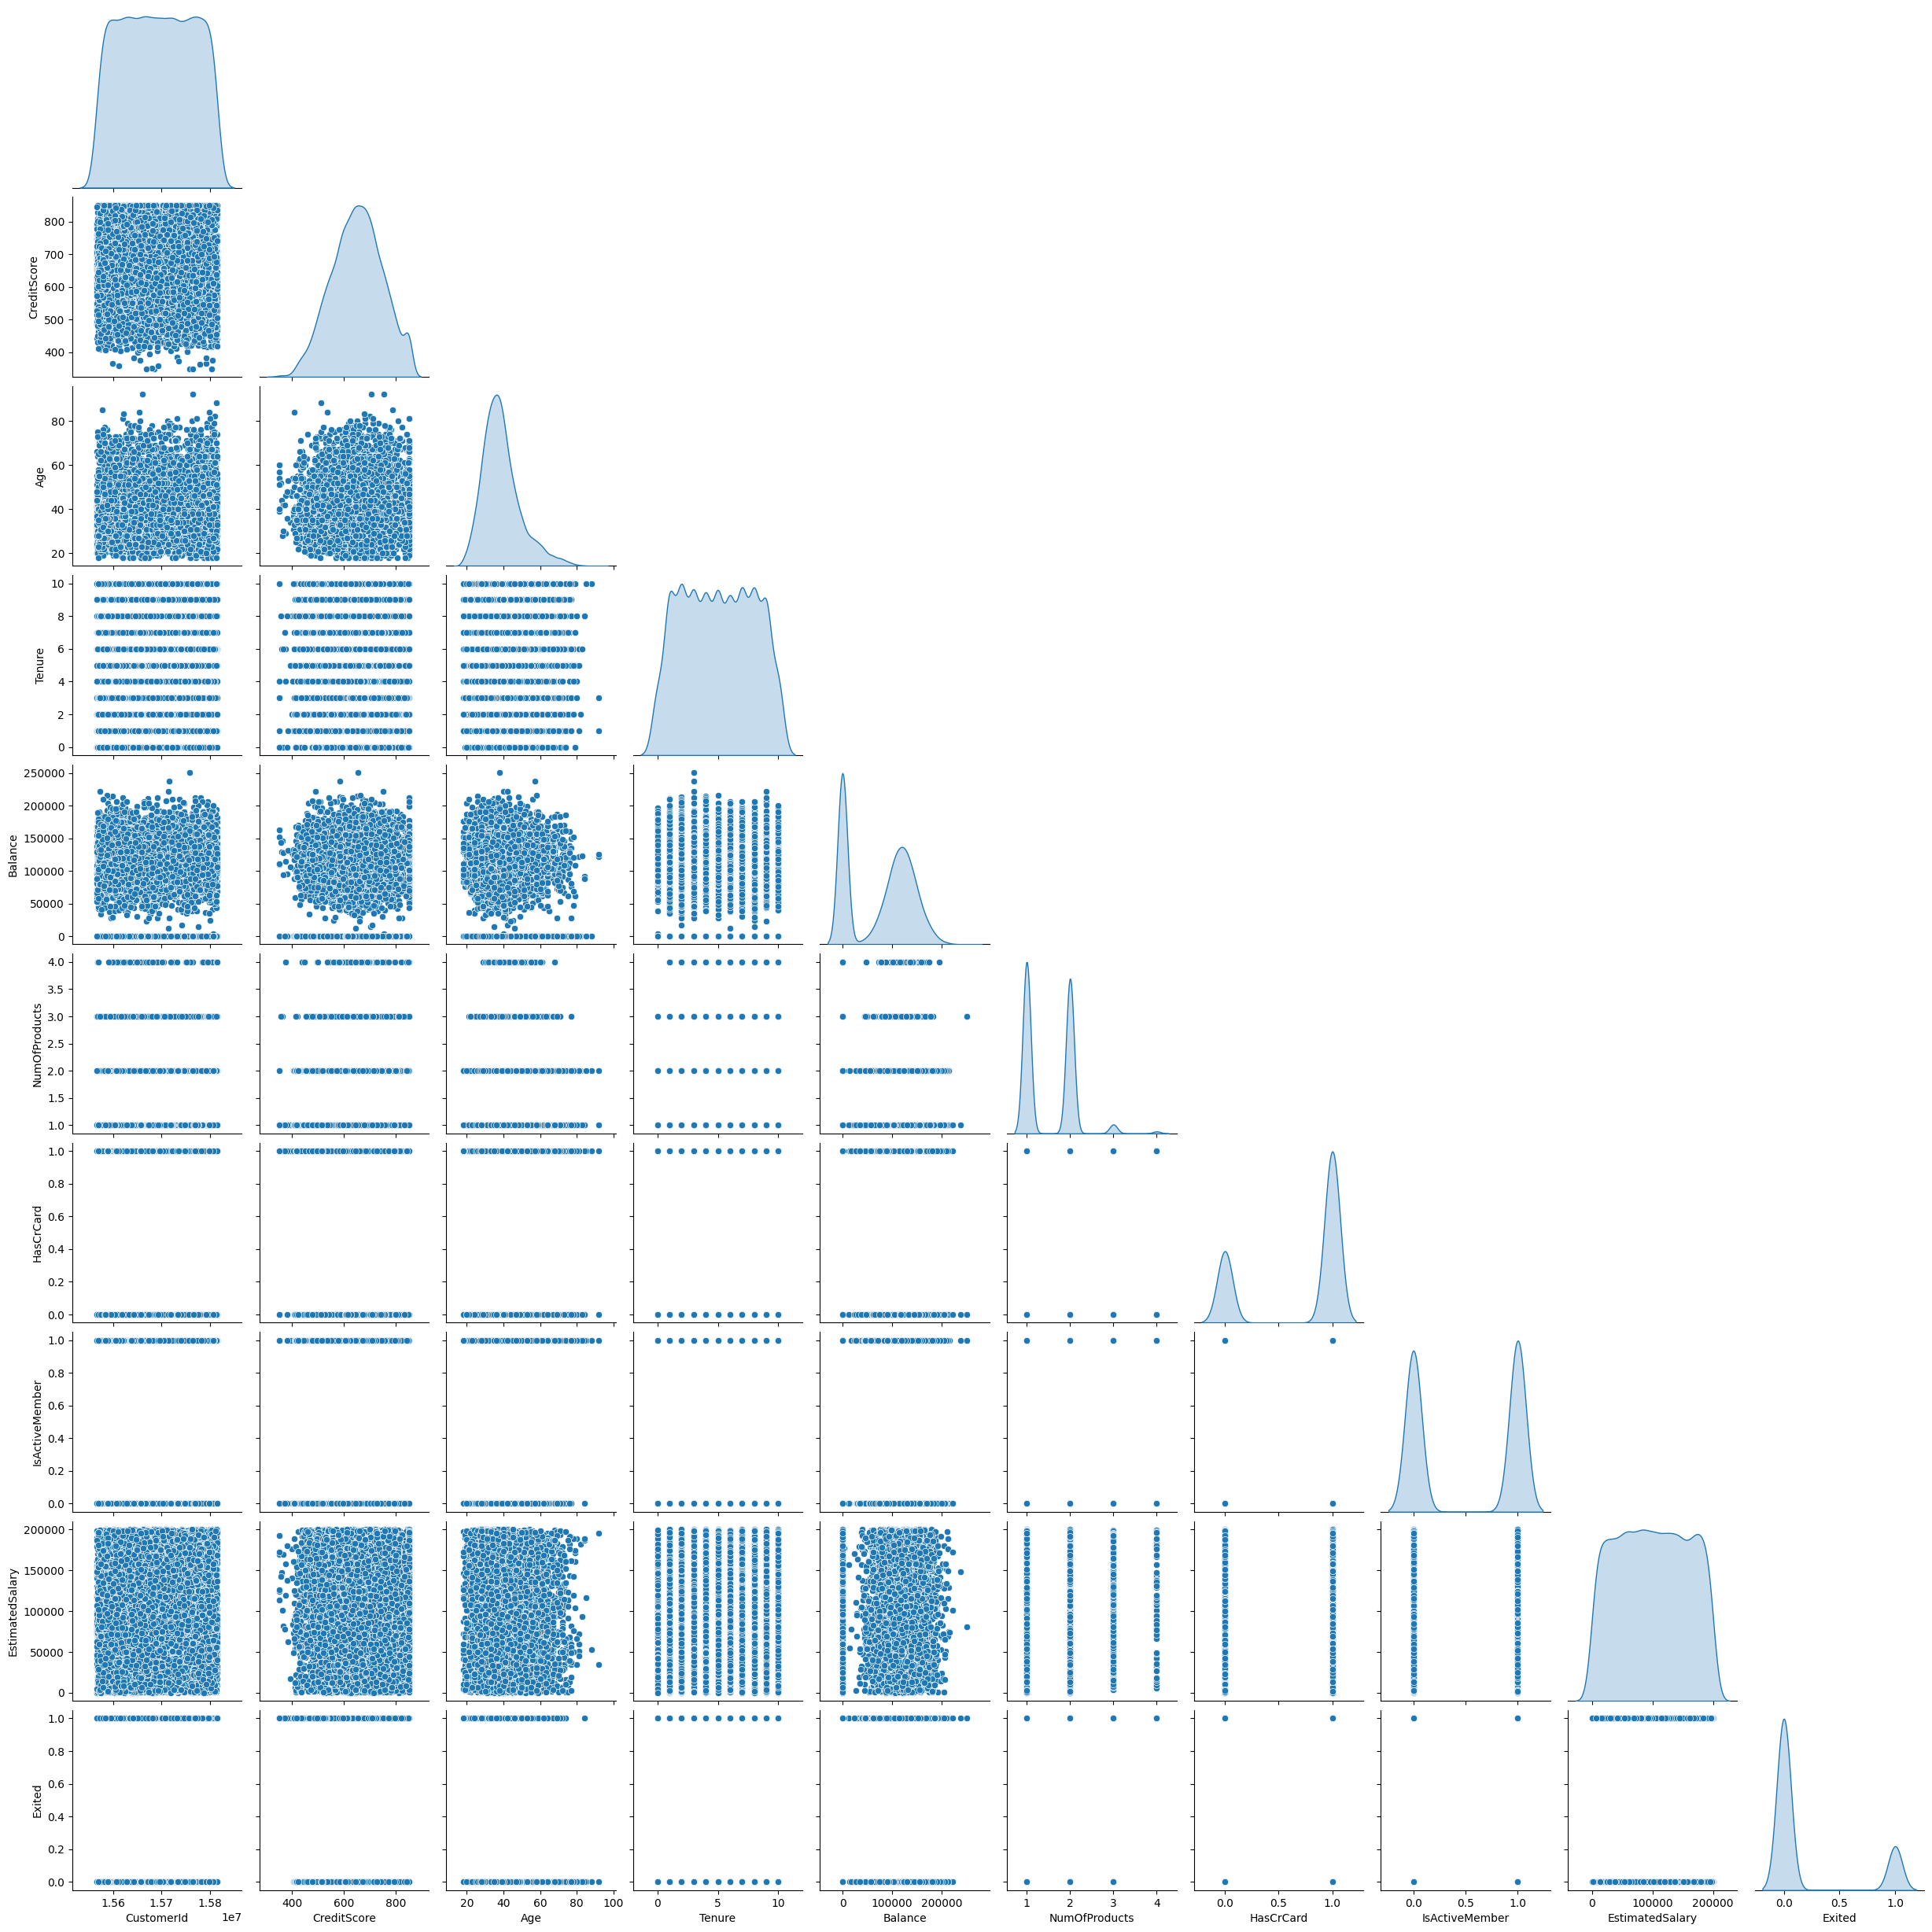

In [21]:
sns.pairplot(df[numerical_columns], diag_kind='kde', corner=True)
plt.show()

**Scatter plots for some combinations of numerical variables**

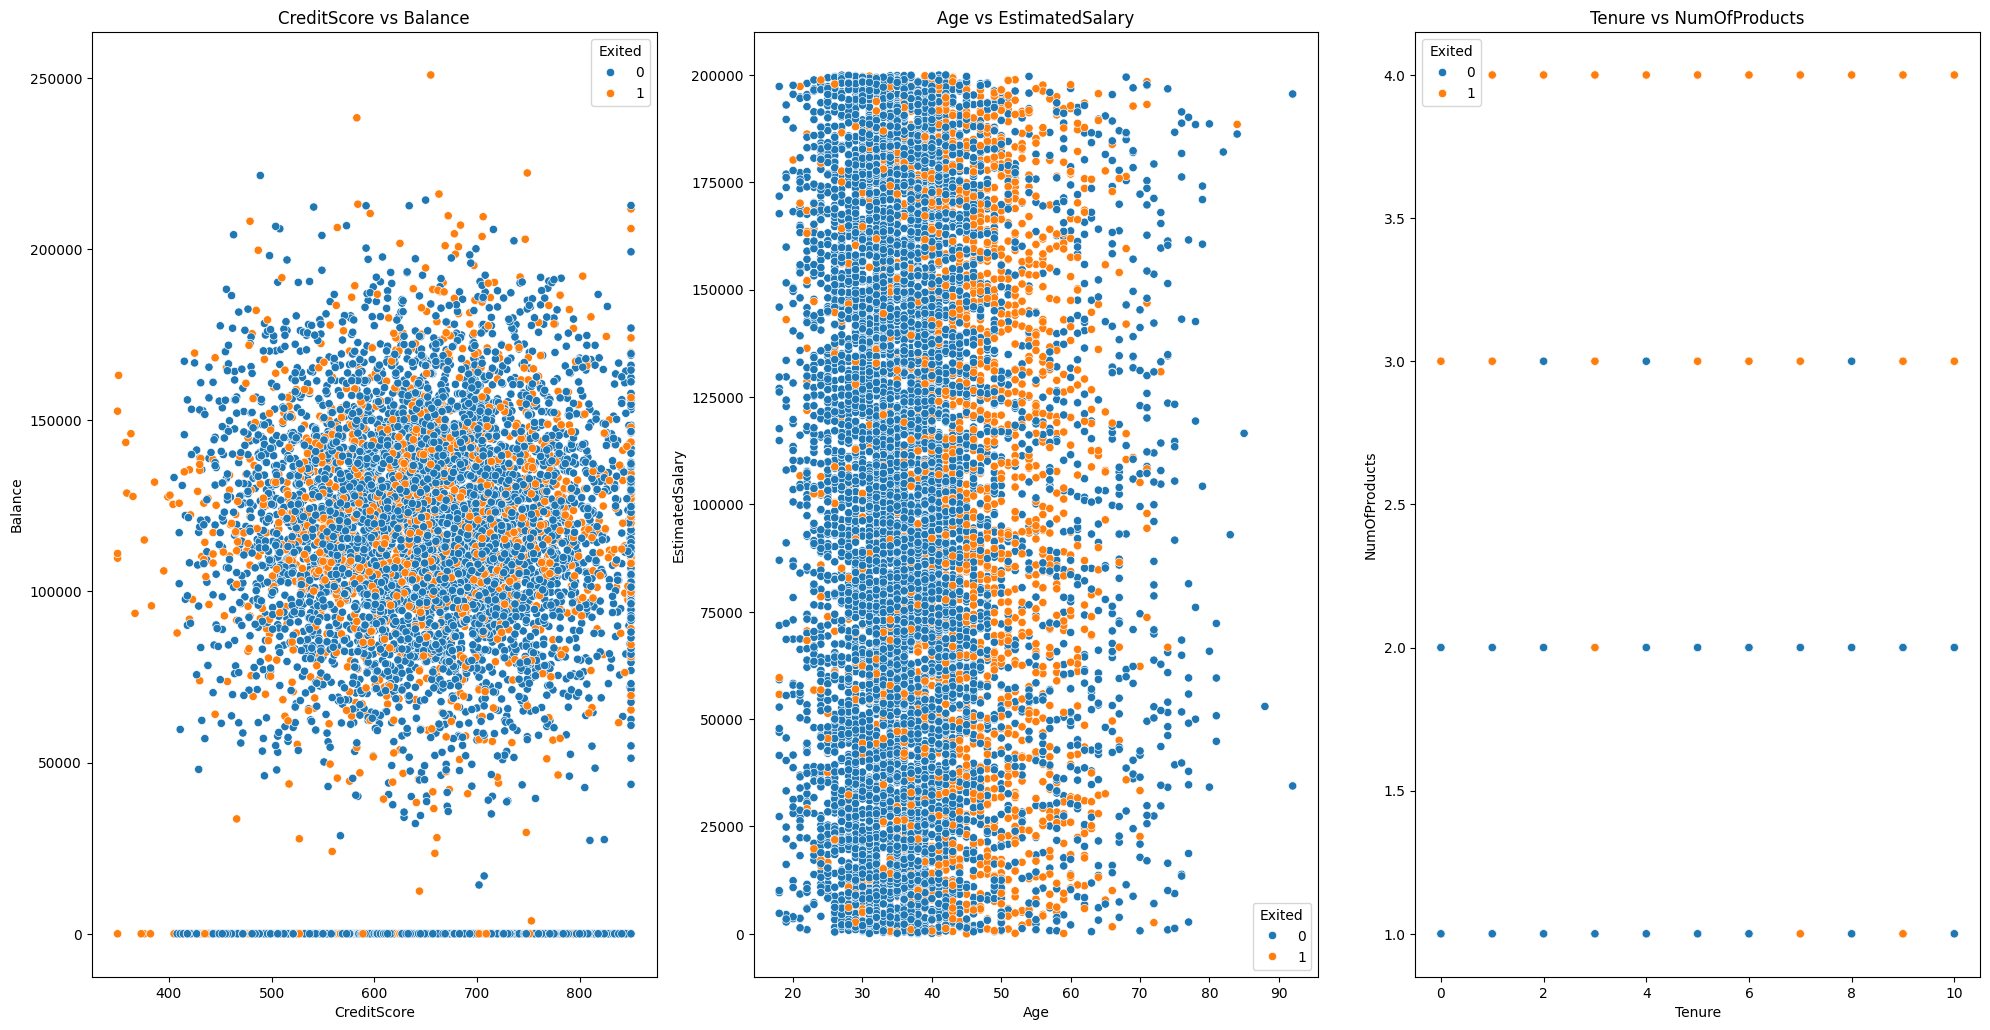

In [24]:
plt.figure(figsize=(20, 20))
pairs = [('CreditScore', 'Balance'), ('Age', 'EstimatedSalary'), ('Tenure', 'NumOfProducts')]
for i, (col1, col2) in enumerate(pairs, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=col1, y=col2, hue=target, data=df)
    plt.legend(title = 'Exited')
    plt.title(f'{col1} vs {col2}')
plt.tight_layout()
plt.show()

# Correlation Insights

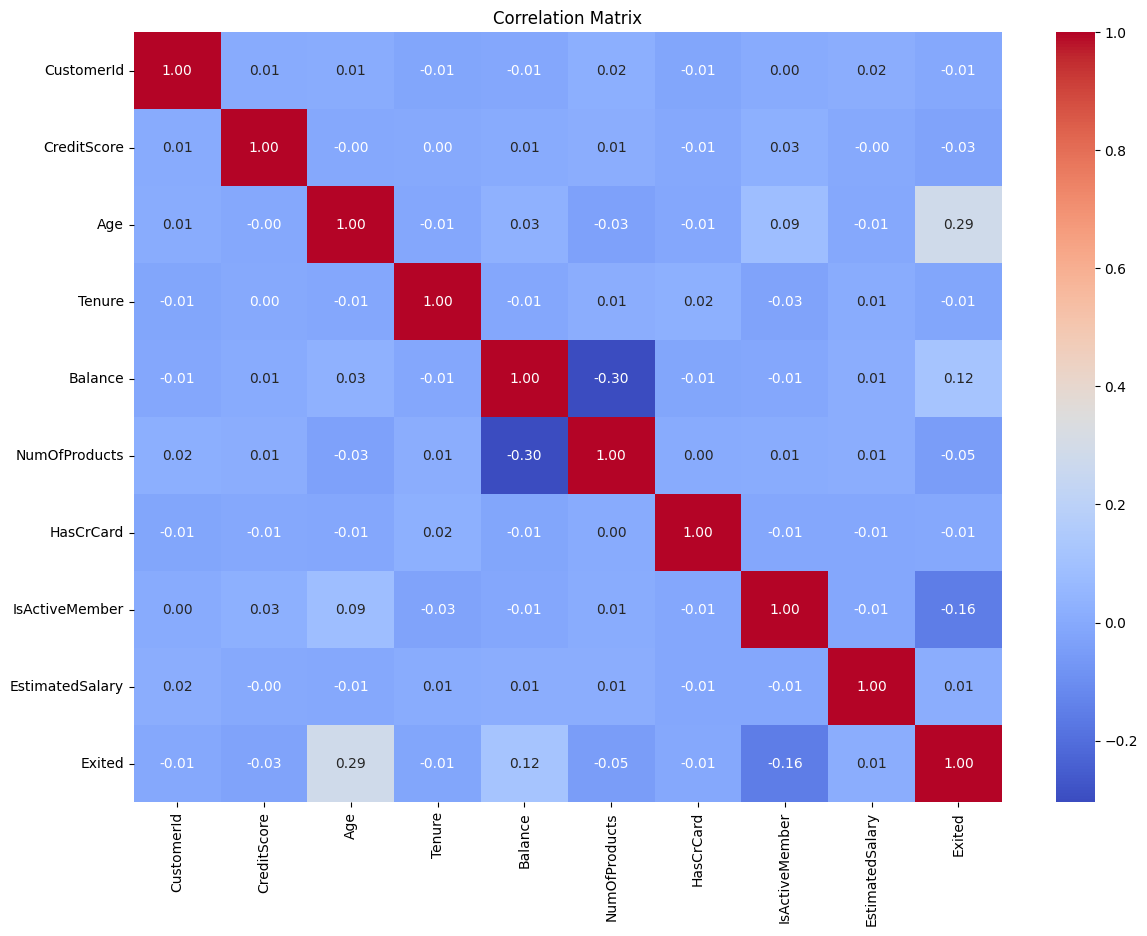

In [25]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Trend Observartion

/tmp/ipython-input-864395269.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age_group = df.groupby('AgeGroup')['Exited'].mean().reset_index()


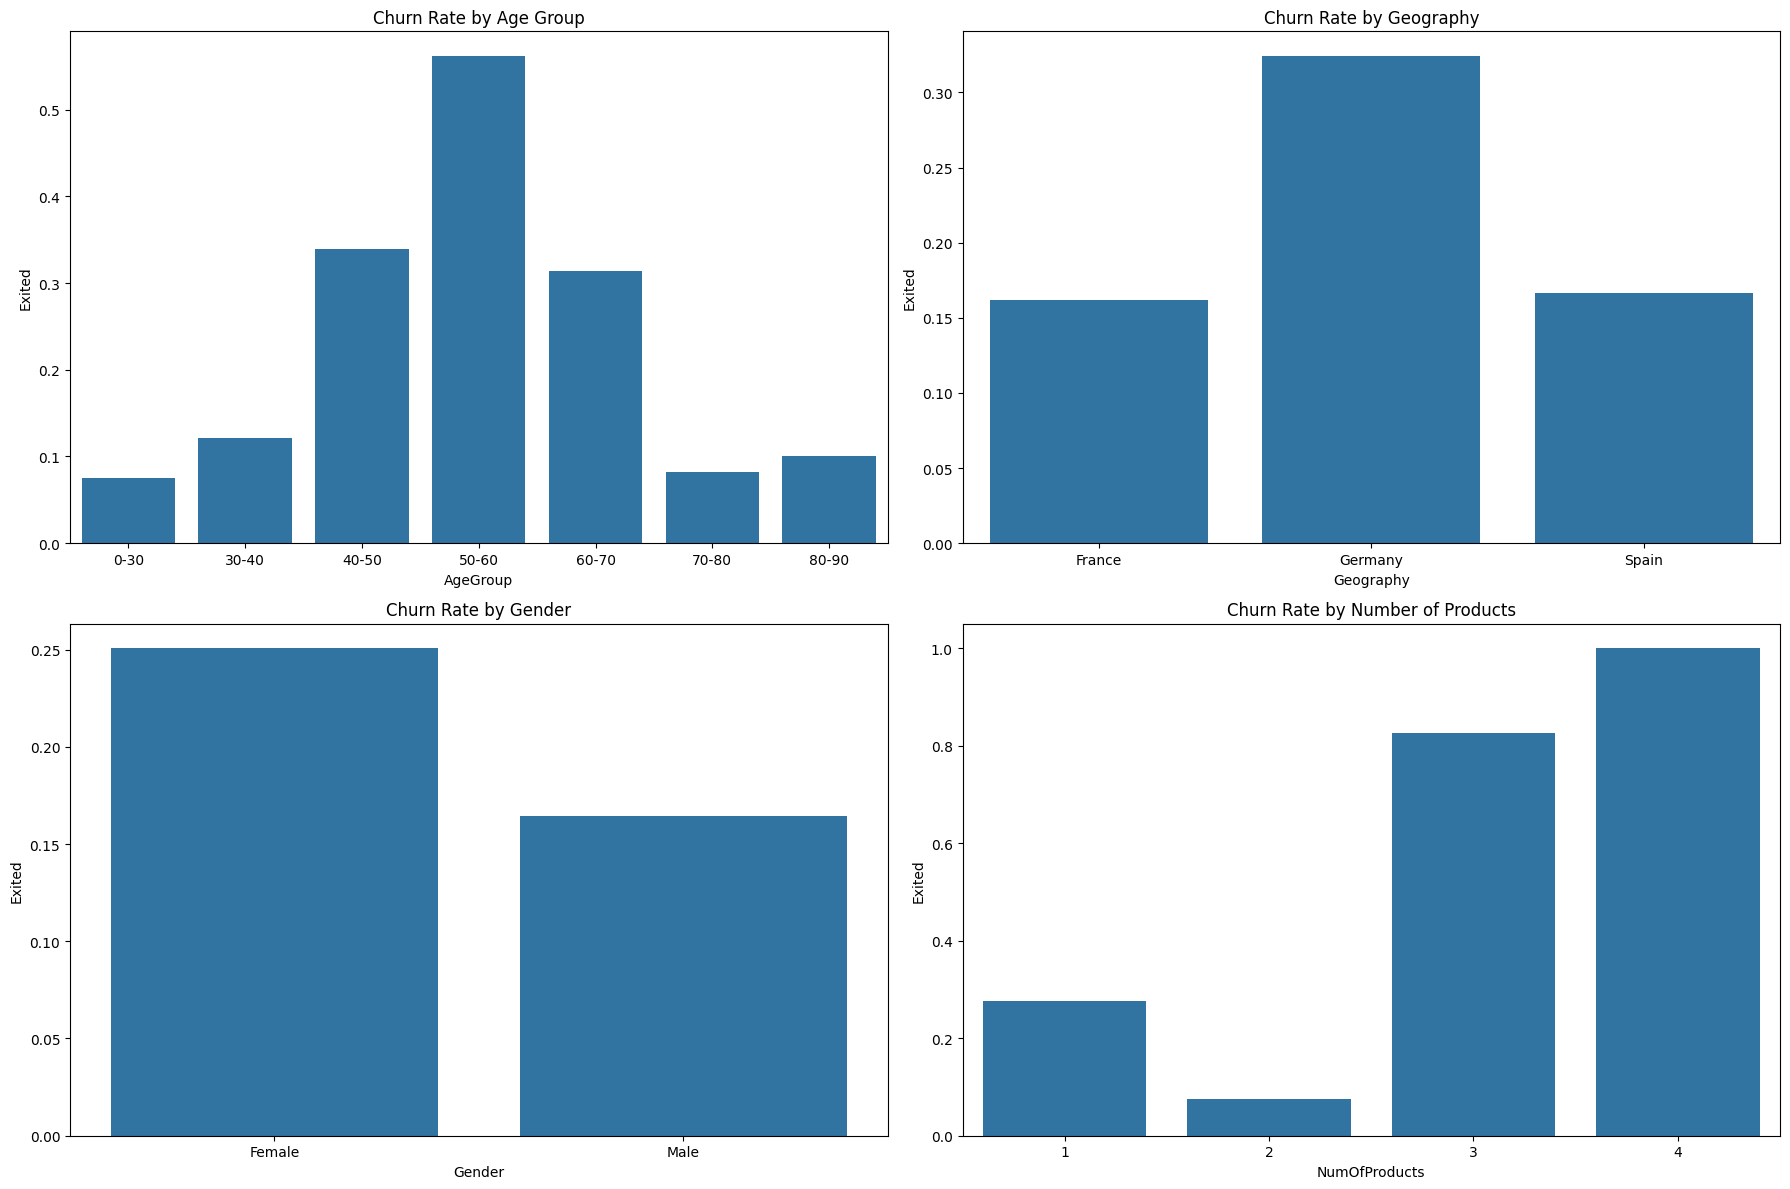

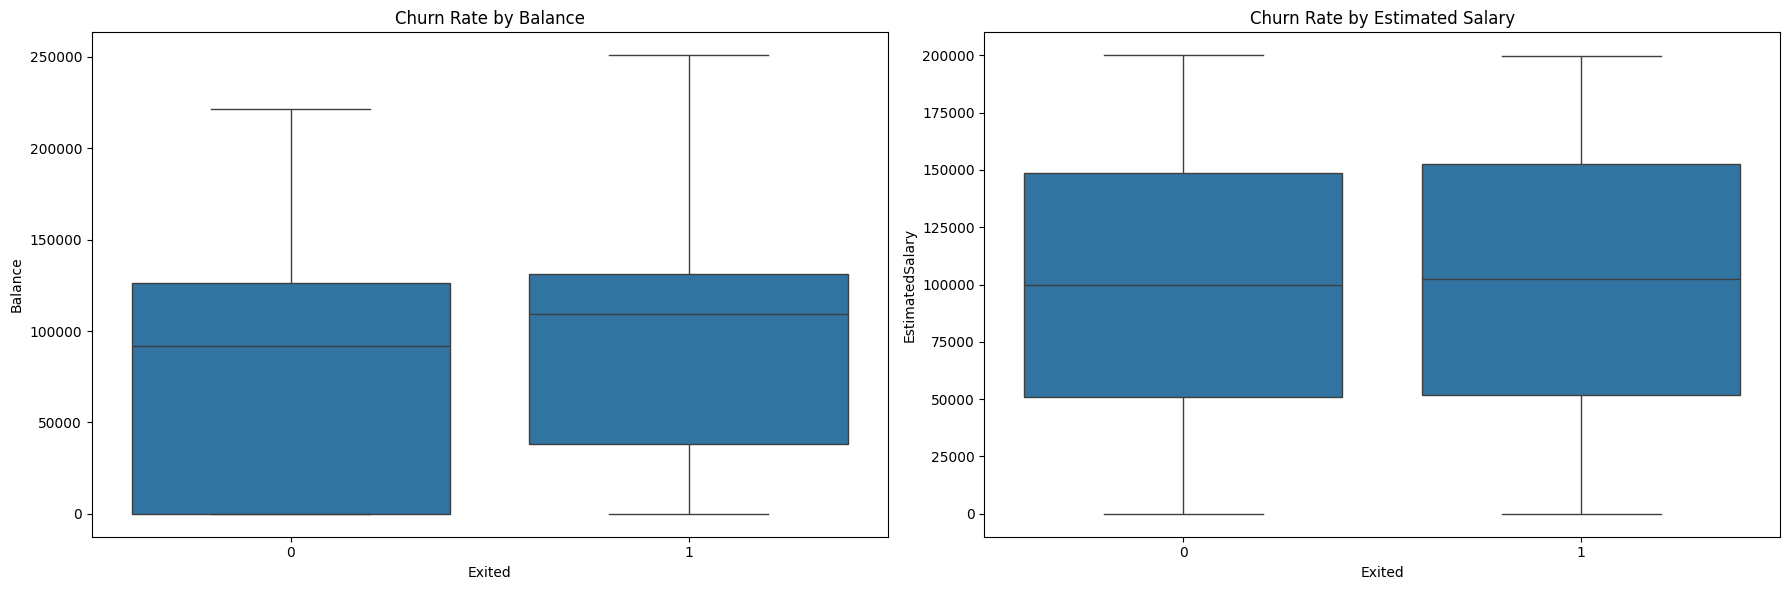

In [26]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 70, 80, 90], labels=['0-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90'])

churn_by_age_group = df.groupby('AgeGroup')['Exited'].mean().reset_index()
churn_by_geography = df.groupby('Geography')['Exited'].mean().reset_index()
churn_by_gender = df.groupby('Gender')['Exited'].mean().reset_index()
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=churn_by_age_group, x='AgeGroup', y='Exited', ax=axes[0, 0])
axes[0, 0].set_title('Churn Rate by Age Group')

sns.barplot(data=churn_by_geography, x='Geography', y='Exited', ax=axes[0, 1])
axes[0, 1].set_title('Churn Rate by Geography')

sns.barplot(data=churn_by_gender, x='Gender', y='Exited', ax=axes[1, 0])
axes[1, 0].set_title('Churn Rate by Gender')

sns.barplot(data=churn_by_products, x='NumOfProducts', y='Exited', ax=axes[1, 1])
axes[1, 1].set_title('Churn Rate by Number of Products')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[0])
axes[0].set_title('Churn Rate by Balance')

sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=axes[1])
axes[1].set_title('Churn Rate by Estimated Salary')

plt.tight_layout()
plt.show()

# Outlier Management

**Finding which columns has outliers**

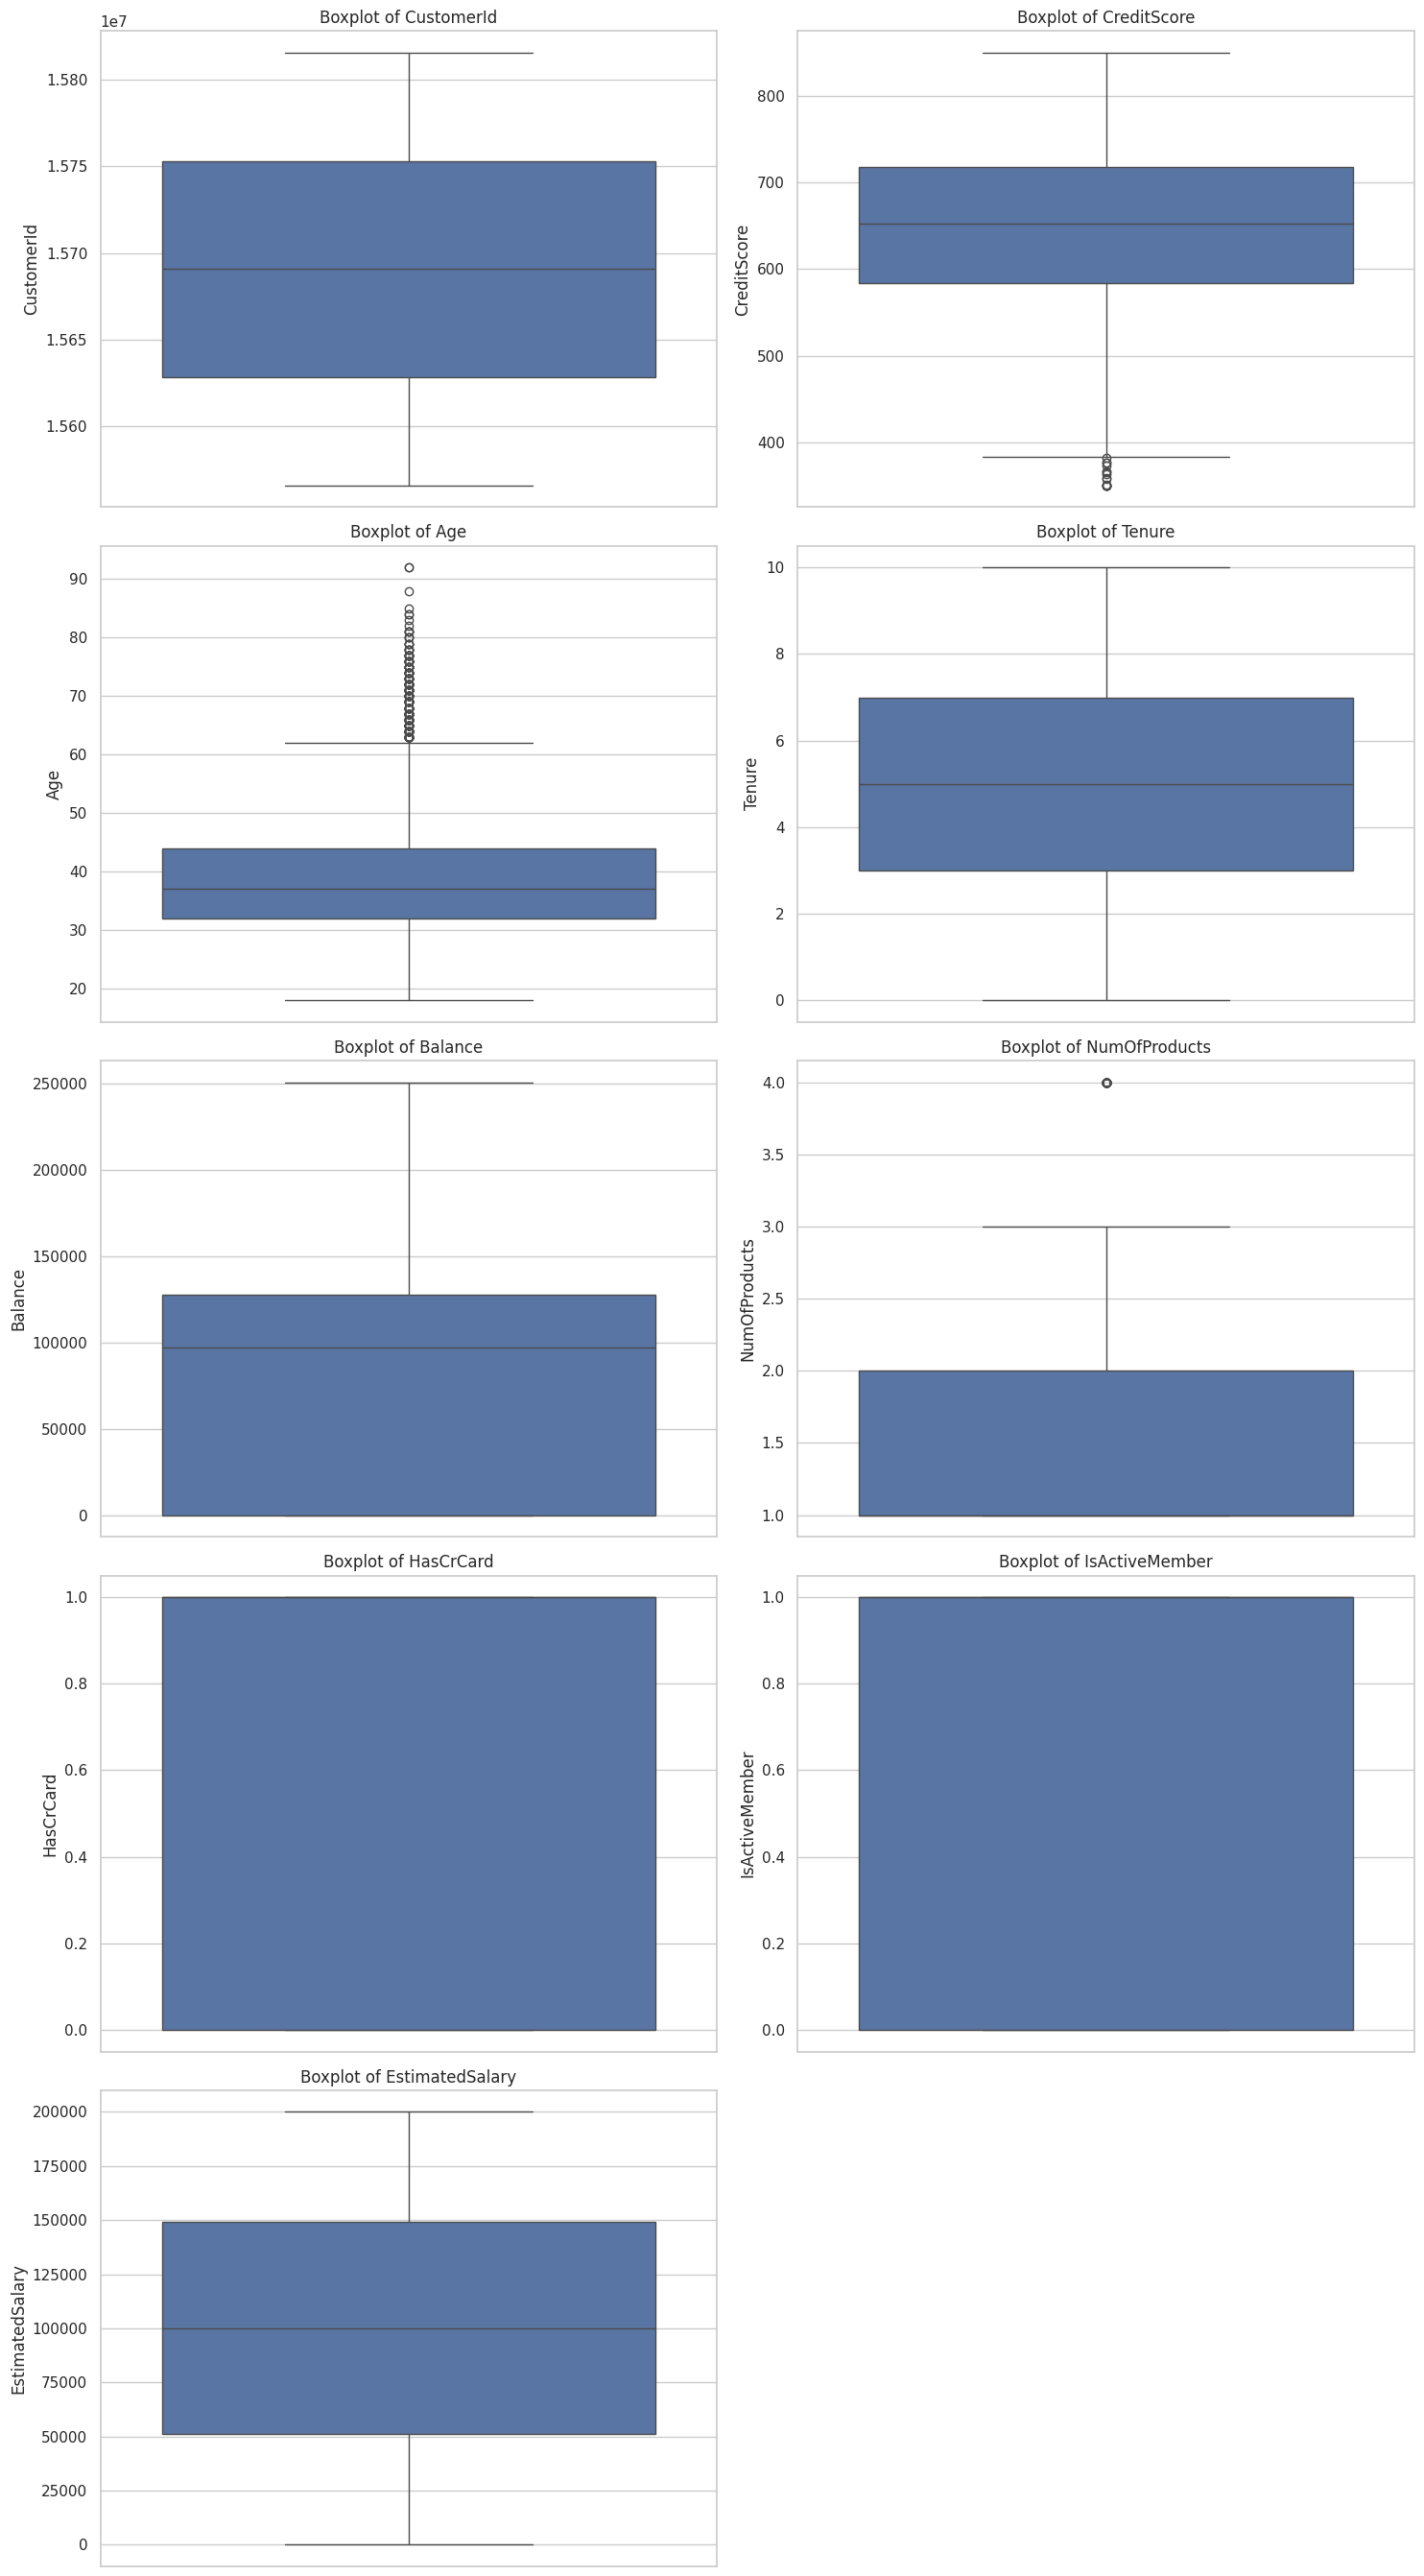

In [27]:
sns.set_theme(style="whitegrid")

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = numeric_columns.drop('Exited')

fig, axes = plt.subplots(nrows=(len(numeric_columns) + 1) // 2, ncols=2, figsize=(15, len(numeric_columns) * 3))

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(data=df, y=column, ax=axes[i])
    axes[i].set_title(f'Boxplot of {column}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Handling Outliers by Capping it with IQR Method**

In [28]:
def cap_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    column = column.apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return column

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = np.delete(numeric_columns, np.where(numeric_columns == 'Exited'))

outlier_columns = []
for col in numeric_columns:
    capped_column = cap_outliers_iqr(df[col])
    if not capped_column.equals(df[col]):
        outlier_columns.append(col)
    df[col] = capped_column

**Checking Columns after Handling Outliers**


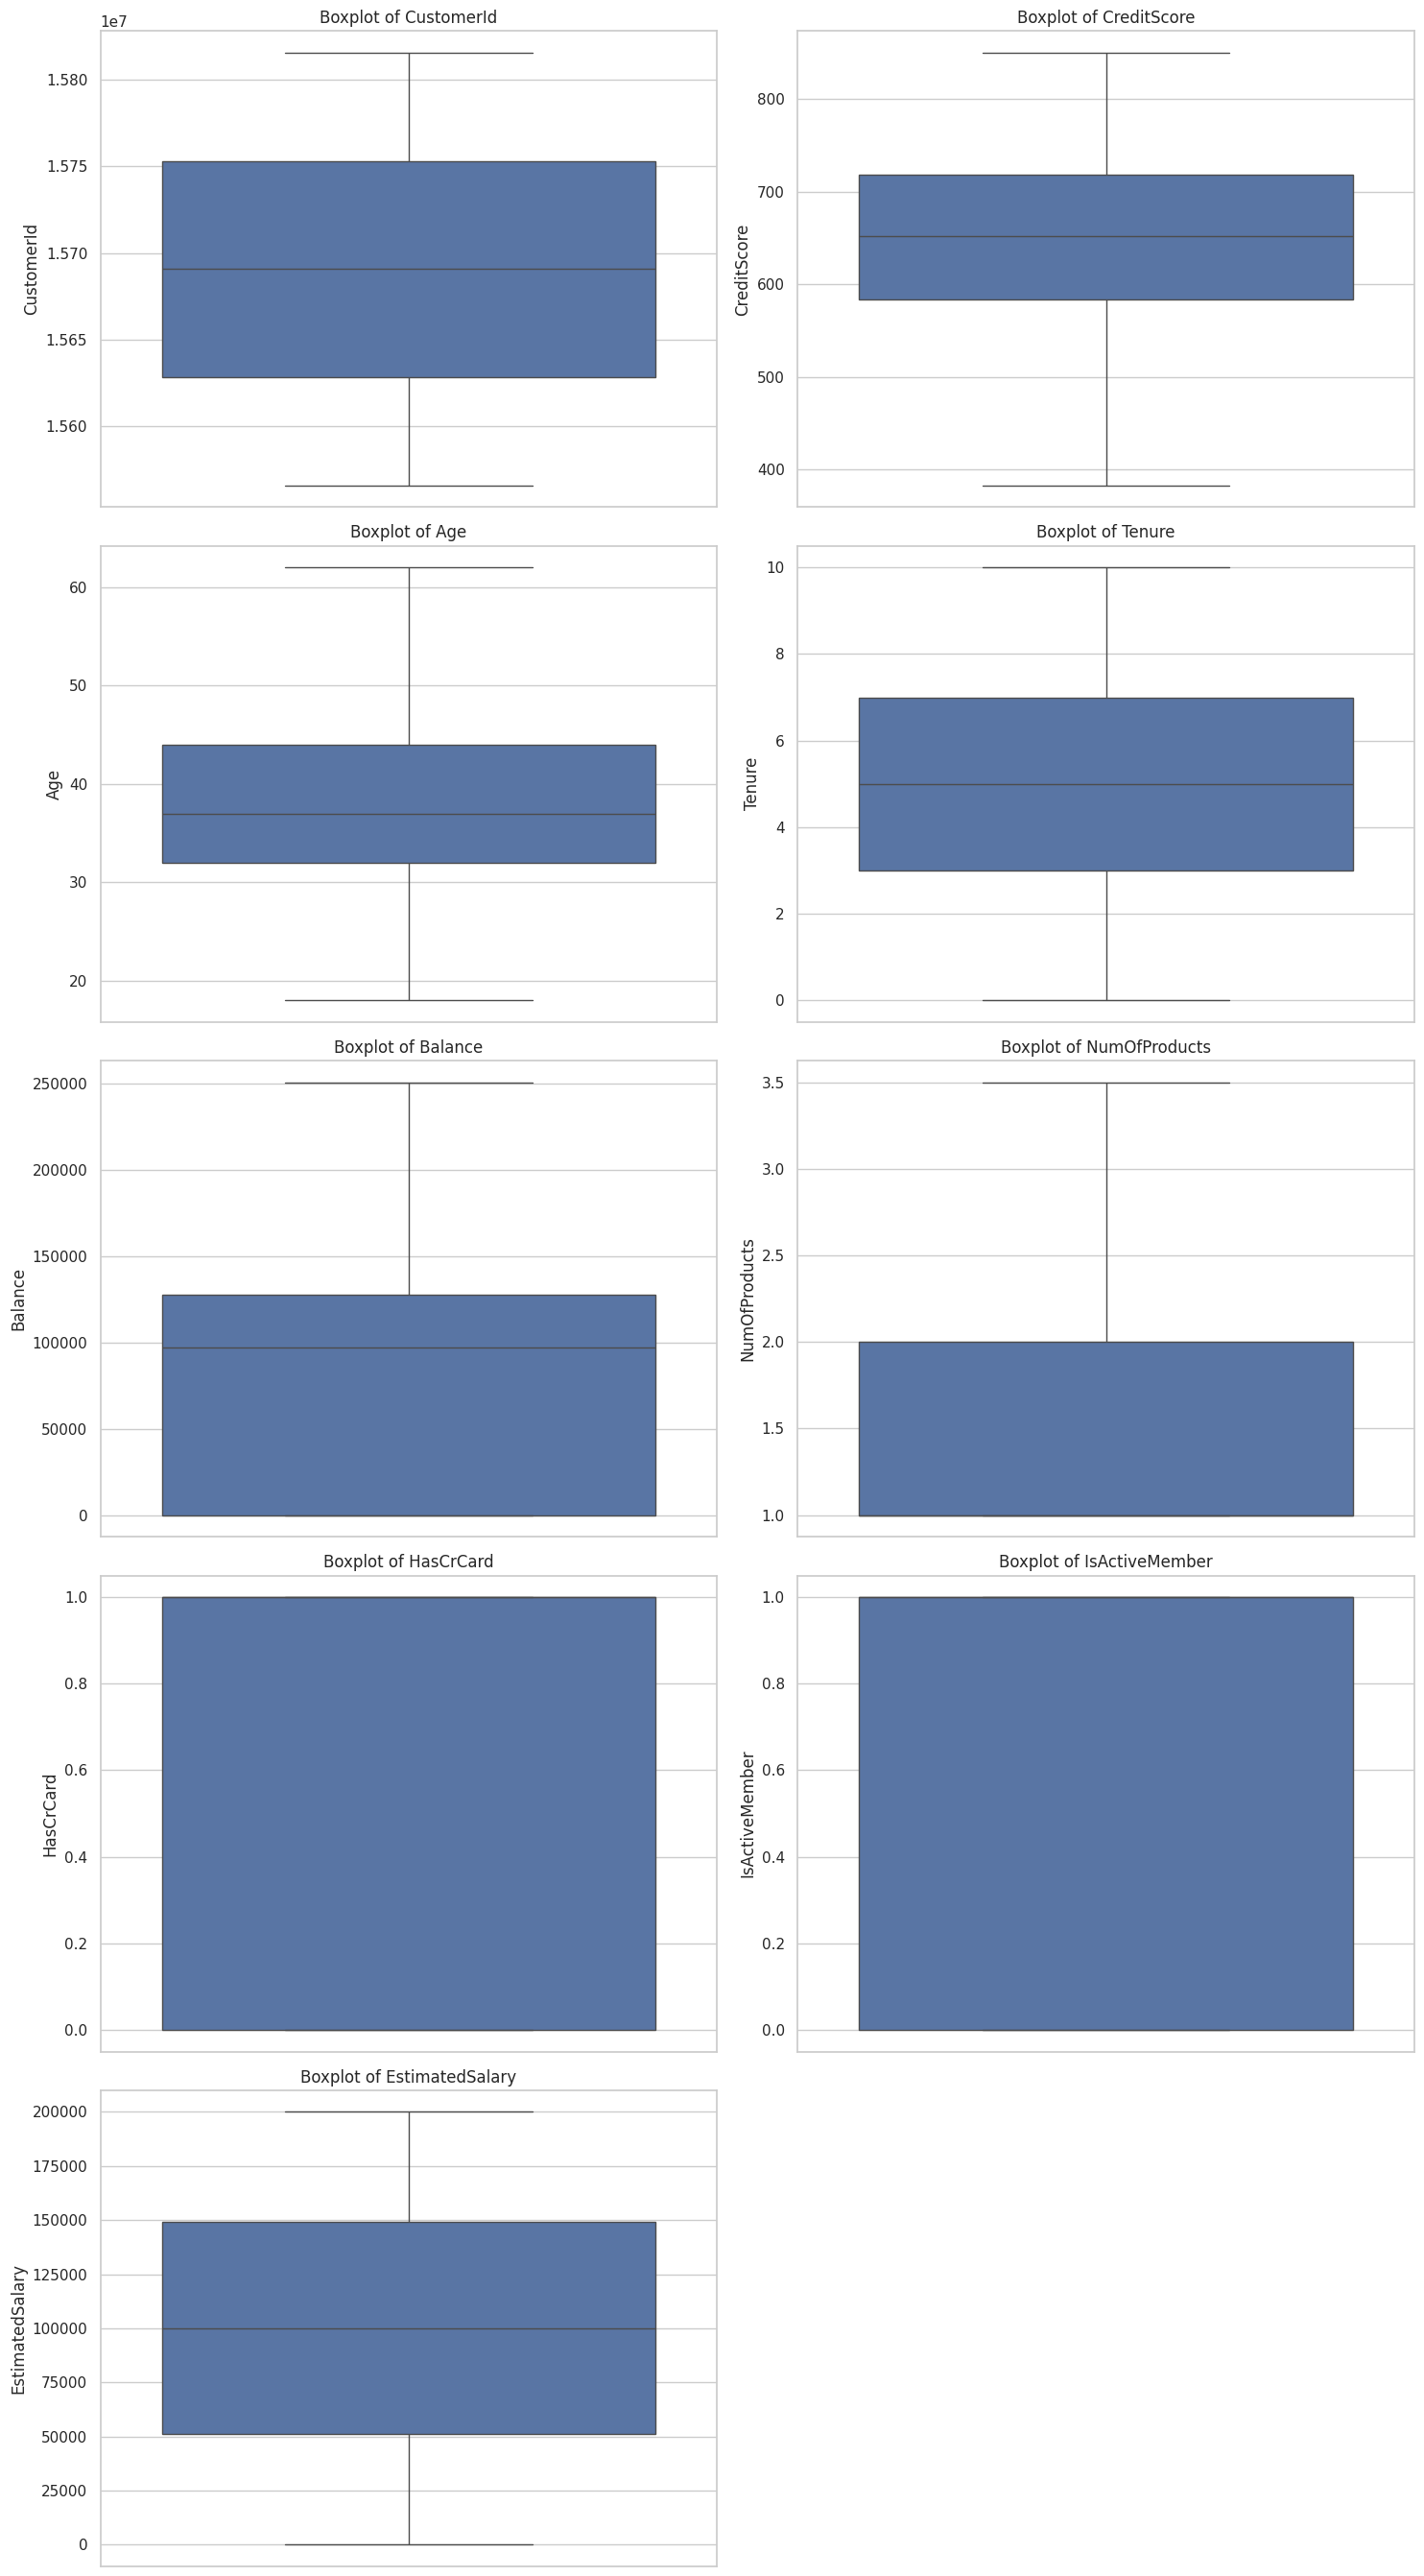

In [29]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=(len(numeric_columns) + 1) // 2, ncols=2, figsize=(15, len(numeric_columns) * 3))

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(data=df, y=column, ax=axes[i])
    axes[i].set_title(f'Boxplot of {column}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Data Preprocessing

In [30]:
df.drop(columns=['CustomerId', 'Surname'], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
0,619.0,France,Female,42.0,2,0.00,1.0,1,1,101348.88,1,40-50
1,608.0,Spain,Female,41.0,1,83807.86,1.0,0,1,112542.58,0,40-50
2,502.0,France,Female,42.0,8,159660.80,3.0,1,0,113931.57,1,40-50
3,699.0,France,Female,39.0,1,0.00,2.0,0,0,93826.63,0,30-40
4,850.0,Spain,Female,43.0,2,125510.82,1.0,1,1,79084.10,0,40-50


In [31]:
df.shape

(10000, 12)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Exited']), df['Exited'],
                                                    test_size=0.2,
                                                    random_state=42)

In [34]:
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AgeGroup
9254,686.0,France,Male,32.0,6,0.00,2.0,1,1,179093.26,30-40
1561,632.0,Germany,Male,42.0,4,119624.60,2.0,1,1,195978.86,40-50
1670,559.0,Spain,Male,24.0,3,114739.92,1.0,1,0,85891.02,0-30
6087,561.0,France,Female,27.0,9,135637.00,1.0,1,0,153080.40,0-30
6669,517.0,France,Male,56.0,9,142147.32,1.0,0,0,39488.04,50-60


In [35]:
numerical_columns = [0, 3, 4, 5, 6, 7, 8, 9]
nominal_columns = [1, 2]
ordinal_columns = [10]

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

handle_numerical = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', MinMaxScaler())
])

In [41]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

handle_nominal = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder())
])

In [47]:
handle_ordinal = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder())
])

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder


preprocessing = ColumnTransformer(transformers=[
    ('numerical', handle_numerical, numerical_columns),
    ('ordinal', handle_ordinal, ordinal_columns),
    ('nominal', handle_nominal, nominal_columns)
], remainder='passthrough')

# Balancing the Scales: Handling Data Imbalance

In [49]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [51]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

In [52]:
pipe_adasyn = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote', adasyn)])

In [54]:
# Apply preprocessing to the training data
X_train_processed = preprocessing.fit_transform(X_train)

# Apply ADASYN to the preprocessed training data
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train_processed, y_train)

In [55]:
X_test_preprocessed = pipe_adasyn.named_steps['preprocessing'].transform(X_test)

# Model Deployment & Evaluation

**Decision Tree**

In [56]:
class_weights = {0: 1, 1: 3}

In [58]:
from sklearn.tree import DecisionTreeClassifier

class_weights = {0: 1, 1: 3}

model_dt = DecisionTreeClassifier(class_weight=class_weights)
model_dt.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(class_weight={0: 1, 1: 3})

In [59]:
y_pred_dt = model_dt.predict(X_test_preprocessed)

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1607
           1       0.44      0.52      0.48       393

    accuracy                           0.78      2000
   macro avg       0.66      0.68      0.67      2000
weighted avg       0.79      0.78      0.78      2000



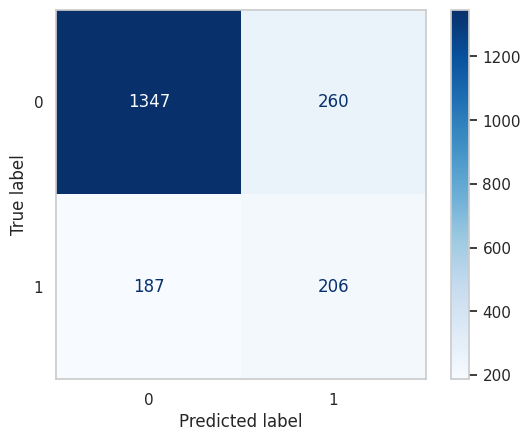

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

unique_classes = np.unique(np.concatenate([y_test, y_pred_dt]))
cm = confusion_matrix(y_test, y_pred_dt, labels=unique_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
fig, ax = plt.subplots()
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.show()

**Random Forest**

In [65]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

In [66]:
model_rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier()

In [67]:
y_pred_rf = model_rf.predict(X_test_preprocessed)

In [68]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1607
           1       0.58      0.60      0.59       393

    accuracy                           0.84      2000
   macro avg       0.74      0.75      0.74      2000
weighted avg       0.84      0.84      0.84      2000



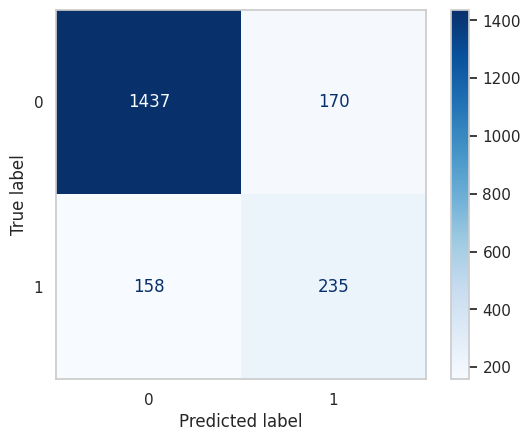

In [69]:
unique_classes = np.unique(np.concatenate([y_test, y_pred_dt]))
cm = confusion_matrix(y_test, y_pred_rf, labels=unique_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
fig, ax = plt.subplots()
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.show()

**SVC Model**

In [71]:
from sklearn.svm import SVC

model_svc = SVC()

In [72]:
model_svc.fit(X_train_resampled, y_train_resampled)

SVC()

In [73]:
y_pred_svc = model_svc.predict(X_test_preprocessed)

In [74]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.94      0.70      0.80      1607
           1       0.39      0.80      0.53       393

    accuracy                           0.72      2000
   macro avg       0.66      0.75      0.66      2000
weighted avg       0.83      0.72      0.74      2000



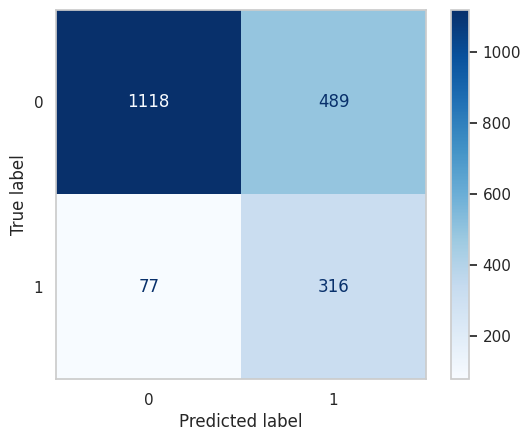

In [75]:
unique_classes = np.unique(np.concatenate([y_test, y_pred_dt]))
cm = confusion_matrix(y_test, y_pred_svc, labels=unique_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
fig, ax = plt.subplots()
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.show()

**KNN Model**

In [77]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)

In [78]:
model_knn.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

In [79]:
y_pred_knn = model_knn.predict(X_test_preprocessed)

In [80]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1607
           1       0.38      0.69      0.49       393

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



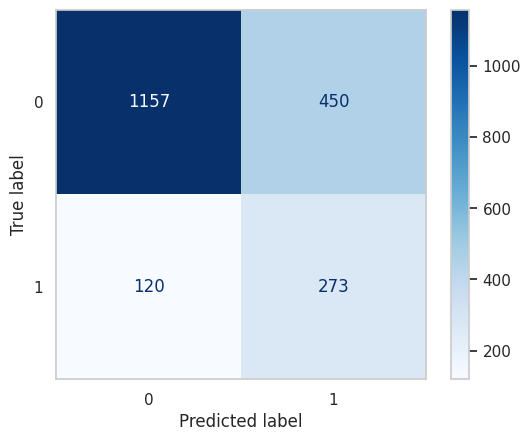

In [81]:
unique_classes = np.unique(np.concatenate([y_test, y_pred_dt]))
cm = confusion_matrix(y_test, y_pred_knn, labels=unique_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
fig, ax = plt.subplots()
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.show()

**XGBoost Classifier**

In [83]:
from xgboost import XGBClassifier

model_xgboost = XGBClassifier()

In [84]:
model_xgboost.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [85]:
y_pred_xgb = model_xgboost.predict(X_test_preprocessed)

In [86]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1607
           1       0.65      0.56      0.60       393

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.76      2000
weighted avg       0.85      0.85      0.85      2000



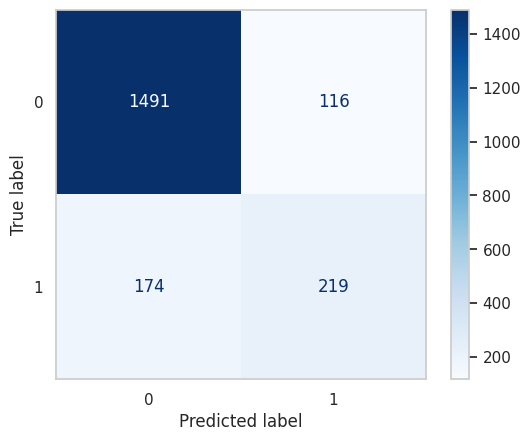

In [87]:
unique_classes = np.unique(np.concatenate([y_test, y_pred_dt]))
cm = confusion_matrix(y_test, y_pred_xgb, labels=unique_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
fig, ax = plt.subplots()
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.show()

**Voting Classifier**

In [89]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('dt', model_dt),
    ('rf', model_rf),
    ('svc', model_svc),
    ('knn', model_knn),
    ('xgb', model_xgboost)
])

In [90]:
voting.fit(X_train_resampled, y_train_resampled)

VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(class_weight={0: 1,
                                                                   1: 3})),
                             ('rf', RandomForestClassifier()), ('svc', SVC()),
                             ('knn', KNeighborsClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))])

In [91]:
y_pred_vote = voting.predict(X_test_preprocessed)

In [92]:
print(classification_report(y_test, y_pred_vote))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1607
           1       0.55      0.62      0.59       393

    accuracy                           0.83      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.84      0.83      0.83      2000

